## Install the Library

In [11]:
!pip install sentence-transformers seaborn

## Import Libraries

In [12]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

## 10 sentences on 3 topics:
 Cricket, Cooking, and Cybersecurity

In [13]:
sentences = [

# Cricket
"The batsman hit a six over the boundary.",
"The bowler delivered a fast yorker.",
"The cricket match went into a thrilling super over.",

# Cooking
"I chopped onions and tomatoes to make curry.",
"The chef baked a chocolate cake in the oven.",
"Adding spices improves the flavor of the soup.",

# Cybersecurity
"Strong passwords protect your online accounts.",
"Encryption keeps data safe from hackers.",
"Firewalls help prevent unauthorized access to networks.",
"Phishing attacks try to steal personal information."
]

len(sentences)

10

## Load Embedding Model

In [14]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Generate Embeddings

In [15]:
embeddings = model.encode(sentences)

## Cosine Similarity

In [16]:
similarity_matrix = cosine_similarity(embeddings)

df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)

df

,The batsman hit a six over the boundary.,The bowler delivered a fast yorker.,The cricket match went into a thrilling super over.,I chopped onions and tomatoes to make curry.,The chef baked a chocolate cake in the oven.,Adding spices improves the flavor of the soup.,Strong passwords protect your online accounts.,Encryption keeps data safe from hackers.,Firewalls help prevent unauthorized access to networks.,Phishing attacks try to steal personal information.
The batsman hit a six over the boundary.,1.000000,0.397775,0.491598,0.108632,0.068271,0.014332,0.008142,-0.023637,-0.031014,-0.013187
The bowler delivered a fast yorker.,0.397775,1.000000,0.361907,0.221870,0.151279,0.110210,0.024275,-0.007674,0.000499,0.032346
The cricket match went into a thrilling super over.,0.491598,0.361907,1.000000,0.076310,0.011291,0.046449,0.033858,0.028417,-0.006343,0.012648
I chopped onions and tomatoes to make curry.,0.108632,0.221870,0.076310,1.000000,0.171089,0.383625,-0.029599,0.061347,0.010853,0.062760
The chef baked a chocolate cake in the oven.,0.068271,0.151279,0.011291,0.171089,1.000000,0.010585,-0.069829,0.067082,0.010515,0.109653
Adding spices improves the flavor of the soup.,0.014332,0.110210,0.046449,0.383625,0.010585,1.000000,0.083478,0.034192,0.074231,0.061807
Strong passwords protect your online accounts.,0.008142,0.024275,0.033858,-0.029599,-0.069829,0.083478,1.000000,0.522088,0.449374,0.569884
Encryption keeps data safe from hackers.,-0.023637,-0.007674,0.028417,0.061347,0.067082,0.034192,0.522088,1.000000,0.425071,0.502900
Firewalls help prevent unauthorized access to networks.,-0.031014,0.000499,-0.006343,0.010853,0.010515,0.074231,0.449374,0.425071,1.000000,0.381870
Phishing attacks try to steal personal information.,-0.013187,0.032346,0.012648,0.062760,0.109653,0.061807,0.569884,0.502900,0.381870,1.000000


## Create Heatmap

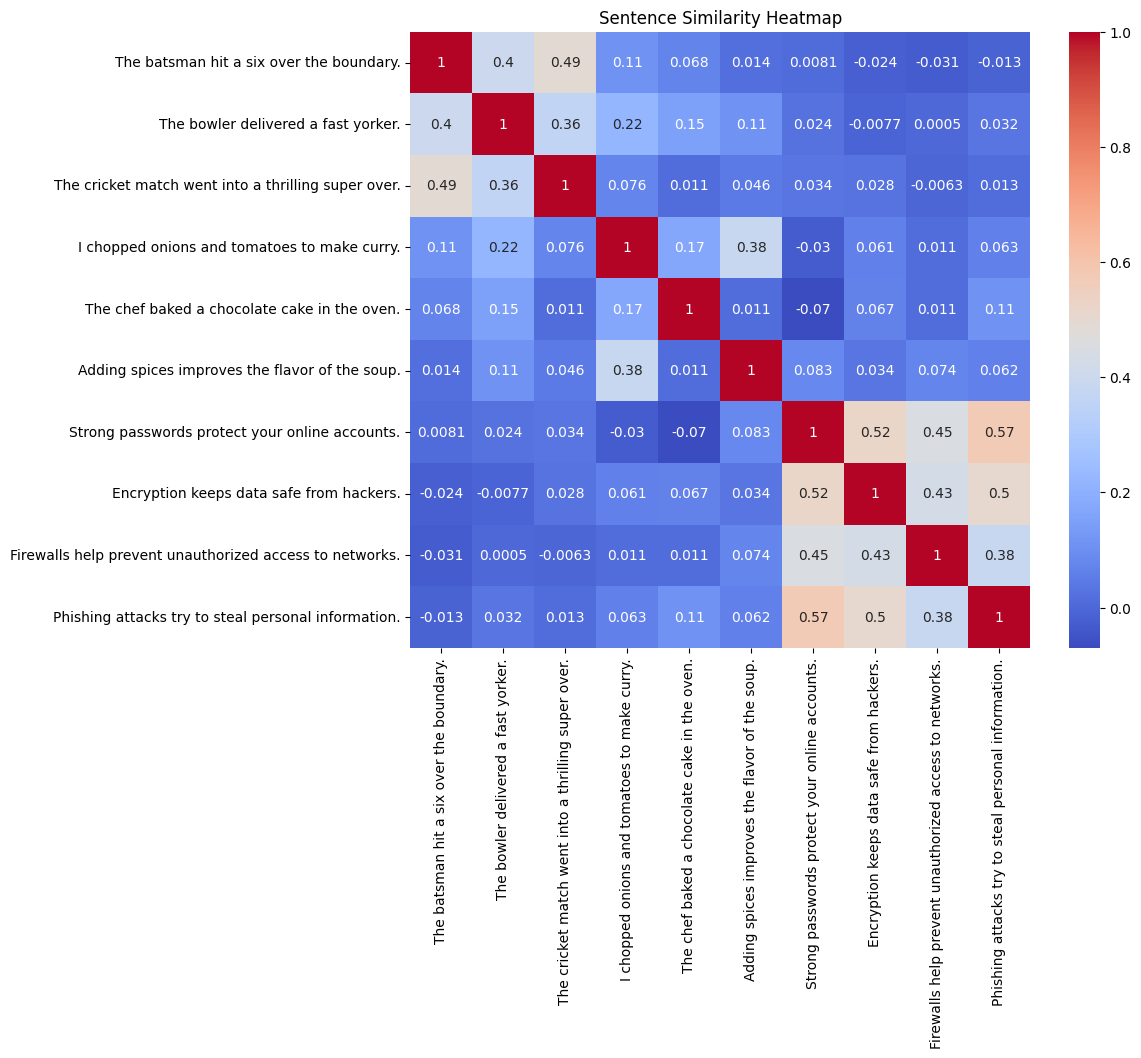

In [17]:
plt.figure(figsize=(10,8))

sns.heatmap(df, annot=True, cmap="coolwarm")

plt.title("Sentence Similarity Heatmap")
plt.show()

## Query Sentence

In [18]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

## Compare With All Sentences

In [19]:
similarities = cosine_similarity(query_embedding, embeddings)[0]

results = list(zip(sentences, similarities))

results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

results_sorted

[('The batsman hit a six over the boundary.', np.float32(0.5591561)),
 ('The bowler delivered a fast yorker.', np.float32(0.5414207)),
 ('The cricket match went into a thrilling super over.',
  np.float32(0.52316564)),
 ('I chopped onions and tomatoes to make curry.', np.float32(0.21826069)),
 ('The chef baked a chocolate cake in the oven.', np.float32(0.12932858)),
 ('Adding spices improves the flavor of the soup.', np.float32(0.07322827)),
 ('Strong passwords protect your online accounts.', np.float32(0.05993028)),
 ('Encryption keeps data safe from hackers.', np.float32(0.011318808)),
 ('Phishing attacks try to steal personal information.',
  np.float32(0.008469662)),
 ('Firewalls help prevent unauthorized access to networks.',
  np.float32(-0.07557097))]

## Print Top 2 Results

In [20]:
print("Query:", query)
print("\nTop 2 most similar sentences:\n")

for sentence, score in results_sorted[:2]:
    print(sentence, " | Similarity:", round(score,3))

Query: The bowler took three wickets in one over

Top 2 most similar sentences:

The batsman hit a six over the boundary.  | Similarity: 0.559
The bowler delivered a fast yorker.  | Similarity: 0.541
